# NjengaData — Visual Dashboard
### Notebook 03 | Visualization Specialist: Stacey Koigu

This notebook reads the processed data from the Analysis team
and produces the four charts that tell the NjengaData story.

**Input:** Four CSV files from `data/processed/`
**Output:** Four charts saved to `data/processed/charts/`

| Chart | File | Story |
|---|---|---|
| Stacked Bar | q1_nairobi_2br_breakdown.csv | Where the money goes in Nairobi |
| County Comparison | q2_county_comparison.csv | Which county builds cheapest |
| Material Trends | q3_material_trends.csv | Five years of inflation |
| Affordability Gap | q4_affordability_gap.csv | Years of income to build |

> *"Numbers tell. Charts show. Stories move."*

---
## Section 1: Imports and Configuration

In [8]:
%pip install pandas matplotlib seaborn --quiet
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Working directory fix ─────────────────────────────────────────
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

# ── Paths ─────────────────────────────────────────────────────────
PROCESSED_PATH = "data/processed"
CHARTS_PATH    = "data/processed/charts"

os.makedirs(CHARTS_PATH, exist_ok=True)

# ── Global style ──────────────────────────────────────────────────
# One style call affects all charts consistently
sns.set_theme(style="whitegrid", font="DejaVu Sans")

# ── Colour palette ────────────────────────────────────────────────
# Five colours — one per cost category — used consistently across all charts
CATEGORY_COLOURS = {
    "Land"       : "#1F4E79",
    "Materials"  : "#2E75B6",
    "Labour"     : "#70AD47",
    "Compliance" : "#ED7D31",
    "Overheads"  : "#A5A5A5",
}

COUNTY_COLOURS = {
    "Nairobi" : "#1F4E79",
    "Kiambu"  : "#2E75B6",
    "Mombasa" : "#ED7D31",
    "Nakuru"  : "#70AD47",
}

print("Libraries loaded.")
print(f"Charts will be saved to: {CHARTS_PATH}")

Note: you may need to restart the kernel to use updated packages.
Libraries loaded.
Charts will be saved to: data/processed/charts


---
## Section 2: Load Processed Data

We load all four CSVs produced by Mohamed's analysis notebook.
We never touch the database — Stacey reads only from processed files.

In [9]:
# Load all four processed datasets
df_q1 = pd.read_csv(os.path.join(PROCESSED_PATH, "q1_nairobi_2br_breakdown.csv"))
df_q2 = pd.read_csv(os.path.join(PROCESSED_PATH, "q2_county_comparison.csv"))
df_q3 = pd.read_csv(os.path.join(PROCESSED_PATH, "q3_material_trends.csv"))
df_q4 = pd.read_csv(os.path.join(PROCESSED_PATH, "q4_affordability_gap.csv"))

print("Datasets loaded:")
print(f"  Q1 — Nairobi 2BR breakdown : {df_q1.shape}")
print(f"  Q2 — County comparison     : {df_q2.shape}")
print(f"  Q3 — Material trends       : {df_q3.shape}")
print(f"  Q4 — Affordability gap     : {df_q4.shape}")

Datasets loaded:
  Q1 — Nairobi 2BR breakdown : (5, 3)
  Q2 — County comparison     : (20, 4)
  Q3 — Material trends       : (18, 3)
  Q4 — Affordability gap     : (4, 6)


---
## Section 3: Chart 1 — Nairobi 2BR Cost Breakdown
**Story:** Where does the money go when building a 2-bedroom house in Nairobi?

A stacked horizontal bar chart. One bar. Five segments.
Land consumes 25.8% before a single brick is laid.
Compliance takes 12.7% — pure regulatory cost.

*Source: CAHF Kenya Housing Development Cost Benchmark Report 2022*

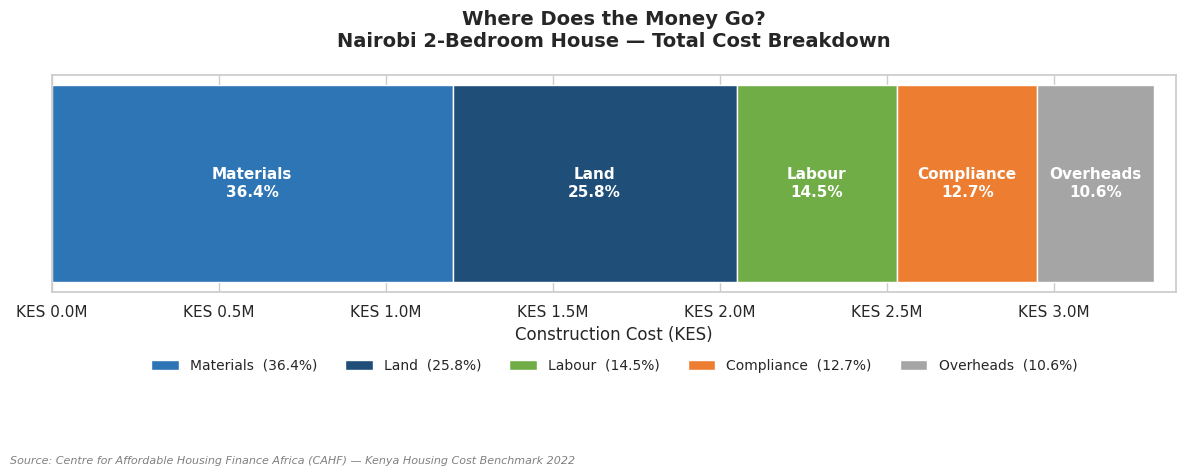

Chart 1 saved: data/processed/charts\chart1_nairobi_breakdown.png


In [51]:
# ── Prepare data ──────────────────────────────────────────────────
# Sort by amount so largest segment sits at the bottom of the stack
q1_sorted = df_q1.sort_values('total_kes', ascending=False)

categories = q1_sorted['cost_category'].tolist()
values     = q1_sorted['total_kes'].tolist()
percentages= q1_sorted['percentage'].tolist()
colours    = [CATEGORY_COLOURS[cat] for cat in categories]

# ── Build chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

# Build the stacked bar segment by segment
left = 0
bars = []
for i, (cat, val, pct, col) in enumerate(zip(categories, values, percentages, colours)):
    bar = ax.barh(
        y      = 0,
        width  = val,
        left   = left,
        color  = col,
        height = 0.5,
        label  = f"{cat}  ({pct}%)"
    )
    bars.append(bar)

    # Label each segment — only if wide enough to fit text
    if pct >= 10:
        ax.text(
            left + val / 2, 0,
            f"{cat}\n{pct}%",
            ha='center', va='center',
            color='white', fontsize=11, fontweight='bold'
        )
    left += val

# ── Formatting ────────────────────────────────────────────────────
ax.set_xlim(0, sum(values) * 1.02)
ax.set_yticks([])
ax.set_xlabel("Construction Cost (KES)", fontsize=12)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"KES {x/1e6:.1f}M")
)

ax.set_title(
    "Where Does the Money Go?\nNairobi 2-Bedroom House — Total Cost Breakdown",
    fontsize=14, fontweight='bold', pad=20
)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=5,
    fontsize=10,
    frameon=False
)

# Source citation — every chart must have one
fig.text(
    0.01, -0.18,
    "Source: Centre for Affordable Housing Finance Africa (CAHF) — Kenya Housing Cost Benchmark 2022",
    fontsize=8, color='grey', style='italic'
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.25)

# ── Save and show ─────────────────────────────────────────────────
chart1_path = os.path.join(CHARTS_PATH, "chart1_nairobi_breakdown.png")
plt.savefig(chart1_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart 1 saved: {chart1_path}")

---
## Section 4: Chart 2 — County Cost Comparison
**Story:** How does the cost of building a 2BR house differ across counties?

Nakuru is KES 1,167,000 cheaper than Nairobi for the exact same house.
The gap is not just price — it is where the cost pressure sits in each market.

*Source: CAHF Kenya Housing Development Cost Benchmark Report 2022*

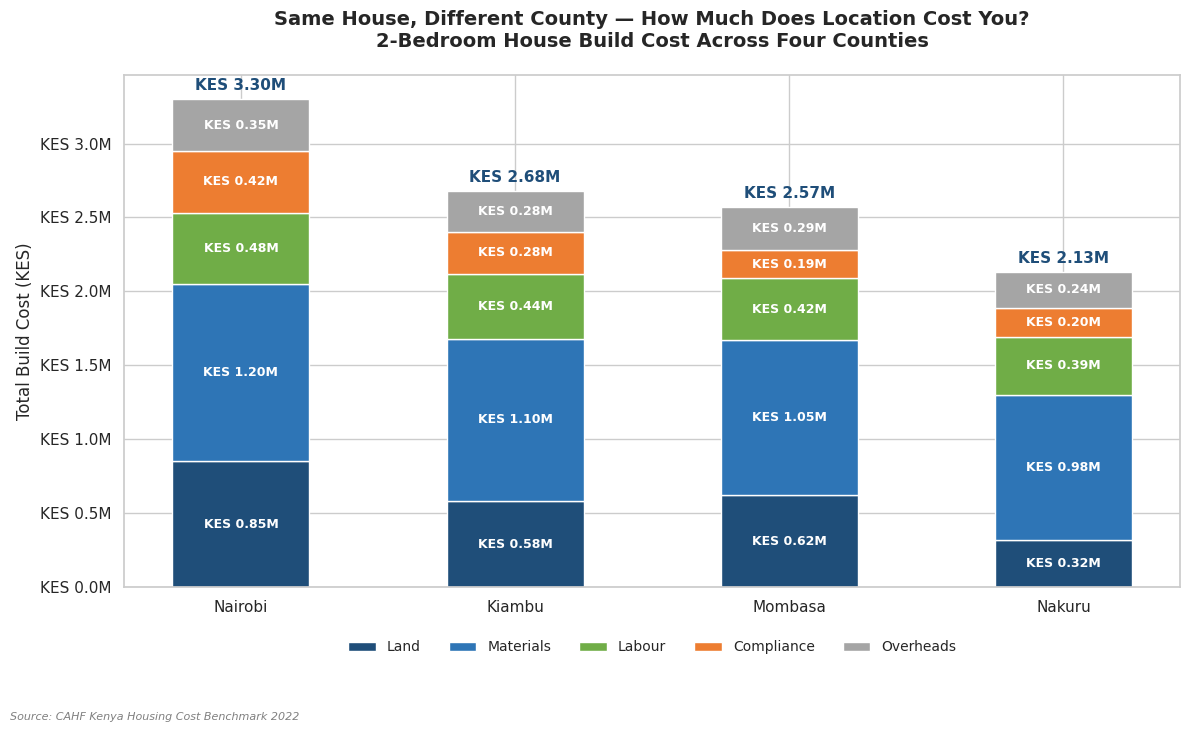

Chart 2 saved: data/processed/charts\chart2_county_comparison.png


In [52]:
# ── Prepare data ──────────────────────────────────────────────────
# Pivot — counties as columns, categories as rows
q2_pivot = df_q2.pivot_table(
    index   = 'cost_category',
    columns = 'county',
    values  = 'total_kes',
    aggfunc = 'sum'
).reindex(['Land', 'Materials', 'Labour', 'Compliance', 'Overheads'])

# County order — most expensive to cheapest left to right
county_order  = df_q2.groupby('county')['total_kes'].sum()\
                      .sort_values(ascending=False).index.tolist()
q2_pivot      = q2_pivot[county_order]

# ── Build chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Build stacked bars county by county
bottom = pd.Series([0.0] * len(county_order), index=county_order)

for category in ['Land', 'Materials', 'Labour', 'Compliance', 'Overheads']:
    values = q2_pivot.loc[category]
    ax.bar(
        x      = county_order,
        height = values,
        bottom = bottom,
        color  = CATEGORY_COLOURS[category],
        label  = category,
        width  = 0.5
    )
    # Label each segment if tall enough
    for i, county in enumerate(county_order):
        segment_height = values[county]
        if segment_height > 80000:
            ax.text(
                i, bottom[county] + segment_height / 2,
                f"KES {segment_height/1e6:.2f}M",
                ha='center', va='center',
                color='white', fontsize=9, fontweight='bold'
            )
    bottom += values

# Total cost label above each bar
totals = df_q2.groupby('county')['total_kes'].sum()
for i, county in enumerate(county_order):
    ax.text(
        i, totals[county] + 40000,
        f"KES {totals[county]/1e6:.2f}M",
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='#1F4E79'
    )

# ── Formatting ────────────────────────────────────────────────────
ax.set_ylabel("Total Build Cost (KES)", fontsize=12)
ax.set_xlabel("")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"KES {x/1e6:.1f}M")
)
ax.set_title(
    "Same House, Different County — How Much Does Location Cost You?\n2-Bedroom House Build Cost Across Four Counties",
    fontsize=14, fontweight='bold', pad=20
)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=5,
    fontsize=10,
    frameon=False
)
fig.text(
    0.01, -0.04,
    "Source: CAHF Kenya Housing Cost Benchmark 2022",
    fontsize=8, color='grey', style='italic'
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)

# ── Save and show ─────────────────────────────────────────────────
chart2_path = os.path.join(CHARTS_PATH, "chart2_county_comparison.png")
plt.savefig(chart2_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart 2 saved: {chart2_path}")

---
## Section 5: Chart 3 — Material Price Trends (2019–2024)
**Story:** How have cement, steel and timber prices moved over five years?

Cement has risen 23% — steadily, with no relief.
Steel spiked sharply in 2021-2022 then softened.
Contractors cannot stockpile cement — every pour costs more than the last.

*Source: KNBS Construction Input Price Index 2019–2024*

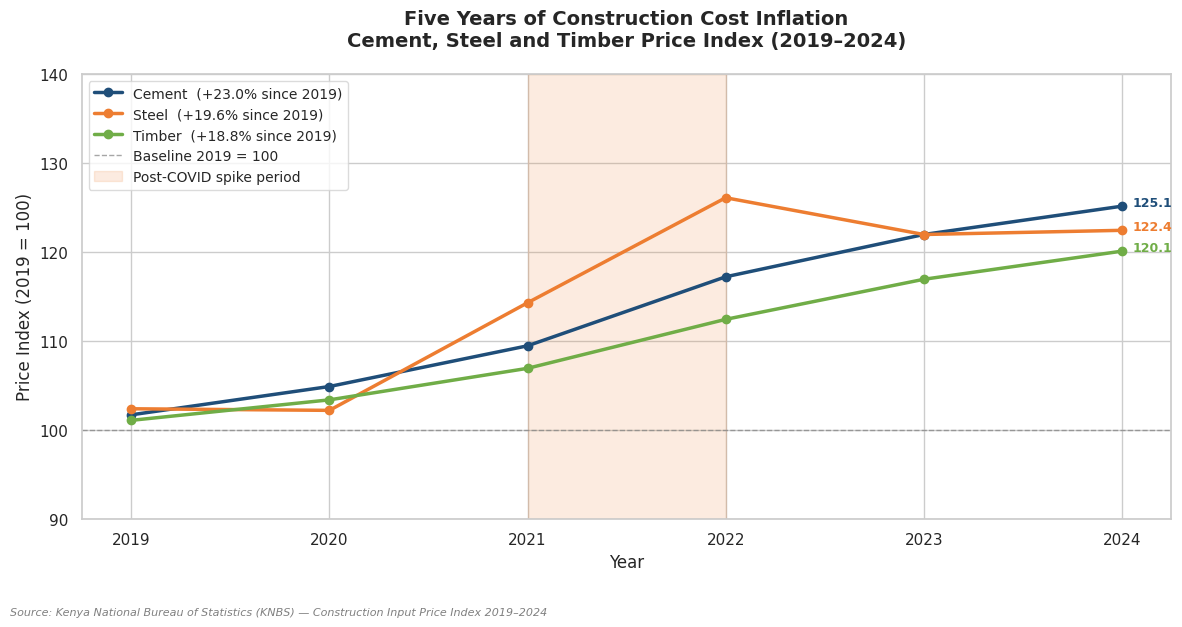

Chart 3 saved: data/processed/charts\chart3_material_trends.png


In [66]:
# ── Prepare data ──────────────────────────────────────────────────
# Pivot — years as index, materials as columns
q3_pivot = df_q3.pivot_table(
    index   = 'year',
    columns = 'material',
    values  = 'avg_annual_index'
)

MATERIAL_COLOURS = {
    'cement' : '#1F4E79',
    'steel'  : '#ED7D31',
    'timber' : '#70AD47',
}
MATERIAL_LABELS = {
        mat: f"{mat.capitalize()}  (+{round((q3_pivot[mat].iloc[-1] - q3_pivot[mat].iloc[0]) / q3_pivot[mat].iloc[0] * 100, 1)}% since 2019)"
    for mat in ['cement', 'steel', 'timber']
}

# ── Build chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for material in ['cement', 'steel', 'timber']:
    ax.plot(
        q3_pivot.index,
        q3_pivot[material],
        color     = MATERIAL_COLOURS[material],
        linewidth = 2.5,
        marker    = 'o',
        markersize= 6,
        label     = MATERIAL_LABELS[material]
    )
    # Annotate the 2024 endpoint with the final index value
    final_val = q3_pivot.loc[2024, material]
    ax.annotate(
        f"{final_val:.1f}",
        xy         = (2024, final_val),
        xytext     = (8, 0),
        textcoords = 'offset points',
        fontsize   = 9,
        color      = MATERIAL_COLOURS[material],
        fontweight = 'bold'
    )

# Reference line at 100 — the 2019 baseline
ax.axhline(
    y         = 100,
    color     = 'grey',
    linewidth = 1,
    linestyle = '--',
    alpha     = 0.7,
    label     = 'Baseline 2019 = 100'
)

# Shade the post-COVID spike period
ax.axvspan(2021, 2022, alpha=0.15, color='#ED7D31', label='Post-COVID spike period')

# ── Formatting ────────────────────────────────────────────────────
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Price Index (2019 = 100)", fontsize=12)
ax.set_xticks(q3_pivot.index)
ax.set_ylim(90, 140)
ax.set_title(
    "Five Years of Construction Cost Inflation\nCement, Steel and Timber Price Index (2019–2024)",
    fontsize=14, fontweight='bold', pad=20
)
ax.legend(
    loc       = 'upper left',
    fontsize  = 10,
    frameon   = True,
    edgecolor = 'lightgrey'
)
fig.text(
    0.01, -0.04,
    "Source: Kenya National Bureau of Statistics (KNBS) — Construction Input Price Index 2019–2024",
    fontsize=8, color='grey', style='italic'
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.12)

# ── Save and show ─────────────────────────────────────────────────
chart3_path = os.path.join(CHARTS_PATH, "chart3_material_trends.png")
plt.savefig(chart3_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart 3 saved: {chart3_path}")

---
## Section 6: Chart 4 — Affordability Gap
**Story:** Can a median household in each county afford to build a 2BR house?

Mombasa is the real affordability trap — not Nairobi.
Lower absolute cost, but significantly lower income means
a Mombasa household needs 5.4 years of full income to build.
Nairobi households need 4.6 years.

No county comes close to affordable. That is the point.

*Source: CAHF 2022 / World Bank Kenya Household Income Data*

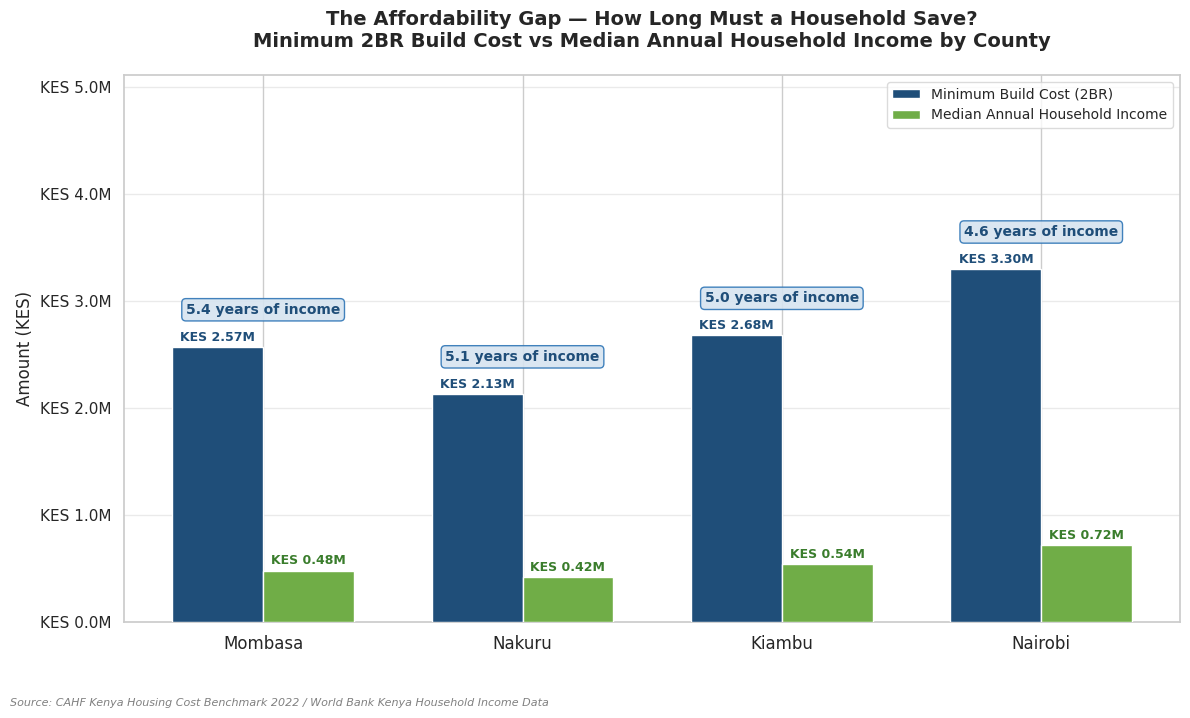

Chart 4 saved: data/processed/charts\chart4_affordability_gap.png


In [54]:
# ── Prepare data ──────────────────────────────────────────────────
# Sort by years of income — most unaffordable first
q4_sorted = df_q4.sort_values('years_of_income', ascending=False)

counties        = q4_sorted['county'].tolist()
build_costs     = q4_sorted['min_build_cost_kes'].tolist()
annual_incomes  = q4_sorted['median_annual_income_kes'].tolist()
years_needed    = q4_sorted['years_of_income'].tolist()

x      = range(len(counties))
width  = 0.35

# ── Build chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(
    [i - width/2 for i in x],
    build_costs,
    width = width,
    color = '#1F4E79',
    label = 'Minimum Build Cost (2BR)',
    zorder= 3
)
bars2 = ax.bar(
    [i + width/2 for i in x],
    annual_incomes,
    width = width,
    color = '#70AD47',
    label = 'Median Annual Household Income',
    zorder= 3
)

# Label build cost bars
for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30000,
        f"KES {bar.get_height()/1e6:.2f}M",
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#1F4E79'
    )

# Label income bars
for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30000,
        f"KES {bar.get_height()/1e6:.2f}M",
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#3A7D2C'
    )

# Annotate years of income above each county pair
for i, (county, years) in enumerate(zip(counties, years_needed)):
    ax.text(
        i, max(build_costs[i], annual_incomes[i]) + 280000,
        f"{years} years of income",
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#1F4E79',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#D6E4F0', edgecolor='#2E75B6', alpha=0.9)
    )

# ── Formatting ────────────────────────────────────────────────────
ax.set_xticks(list(x))
ax.set_xticklabels(counties, fontsize=12)
ax.set_ylabel("Amount (KES)", fontsize=12)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"KES {x/1e6:.1f}M")
)
ax.set_title(
    "The Affordability Gap — How Long Must a Household Save?\n"
    "Minimum 2BR Build Cost vs Median Annual Household Income by County",
    fontsize=14, fontweight='bold', pad=20
)
ax.legend(
    loc            = 'upper right',
    fontsize       = 10,
    frameon        = True,
    edgecolor      = 'lightgrey'
)
ax.set_ylim(0, max(build_costs) * 1.55)
ax.grid(axis='y', alpha=0.4, zorder=0)

fig.text(
    0.01, -0.02,
    "Source: CAHF Kenya Housing Cost Benchmark 2022 / World Bank Kenya Household Income Data",
    fontsize=8, color='grey', style='italic'
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.10)

# ── Save and show ─────────────────────────────────────────────────
chart4_path = os.path.join(CHARTS_PATH, "chart4_affordability_gap.png")
plt.savefig(chart4_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart 4 saved: {chart4_path}")

---

## CHART 5 — The proof              "Two independent sources. Same story."
These are not estimates.
CAHF benchmarks align closely with real Kemika
project BOQs from 2023 and 2024.
Where they diverge — land and materials rising
in 2024 — that is real inflation showing up
in real projects.

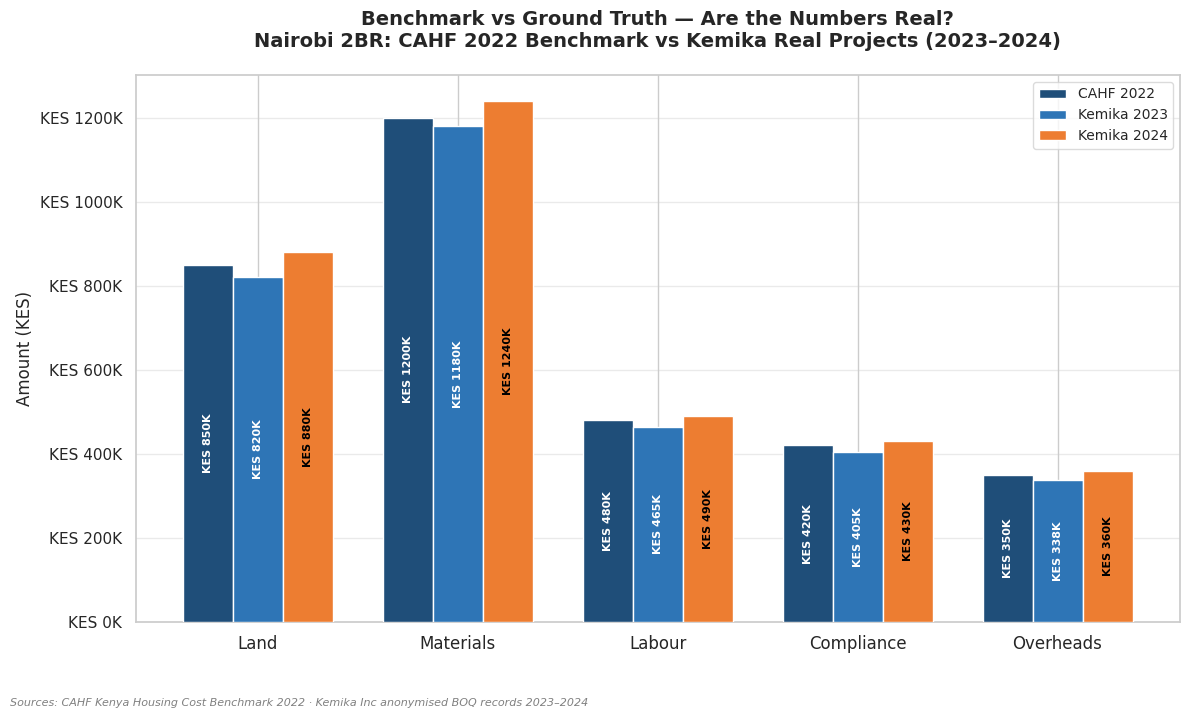

Chart 5 saved: data/processed/charts\chart5_benchmark_vs_real.png


In [32]:
# ── Prepare data ──────────────────────────────────────────────────
df_q5['source_year'] = df_q5['source'] + ' ' + df_q5['year'].astype(str)
q5_pivot = df_q5.pivot_table(
    index   = 'cost_category',
    columns = 'source_year',
    values  = 'total_kes'
).reindex(['Land', 'Materials', 'Labour', 'Compliance', 'Overheads'])

SOURCE_COLOURS = {
    'CAHF 2022'   : '#1F4E79',
    'Kemika 2023' : '#2E75B6',
    'Kemika 2024' : '#ED7D31',
}

# ── Build chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

x     = range(len(q5_pivot.index))
width = 0.25

for i, col in enumerate(q5_pivot.columns):
    bars = ax.bar(
        [j + (i - 1) * width for j in x],
        q5_pivot[col],
        width  = width,
        color  = SOURCE_COLOURS[col],
        label  = col,
        zorder = 3
    )
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f"KES {height/1e3:.0f}K",
            ha='center', va='center',
            fontsize=8, fontweight='bold', rotation=90,
            color='white' if bar.get_facecolor()[0] < 0.6 else 'black'
        )

# ── Formatting ────────────────────────────────────────────────────
ax.set_xticks([j + 0 for j in x])
ax.set_xticklabels(q5_pivot.index, fontsize=12)
ax.set_ylabel("Amount (KES)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"KES {v/1e3:.0f}K"))
ax.set_title(
    "Benchmark vs Ground Truth — Are the Numbers Real?\n"
    "Nairobi 2BR: CAHF 2022 Benchmark vs Kemika Real Projects (2023–2024)",
    fontsize=14, fontweight='bold', pad=20
)
ax.legend(
    loc      = 'upper right',
    fontsize = 10,
    frameon  = True,
    edgecolor= 'lightgrey'
)
ax.grid(axis='y', alpha=0.4, zorder=0)
fig.text(
    0.01, -0.02,
    "Sources: CAHF Kenya Housing Cost Benchmark 2022 · Kemika Inc anonymised BOQ records 2023–2024",
    fontsize=8, color='grey', style='italic'
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.10)

# ── Save and show ─────────────────────────────────────────────────
chart5_path = os.path.join(CHARTS_PATH, "chart5_benchmark_vs_real.png")
plt.savefig(chart5_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart 5 saved: {chart5_path}")

---
## The solution
NjengaData gives every Kenyan homeowner
a benchmark to walk into a contractor meeting with.
Not a guess. A number. Per category. Per county.

In [ ]:
# ── Homeowner Cost Checker ────────────────────────────────────────
# This cell shows how a homeowner benchmarks a contractor quote

# ── Inputs — homeowner changes these two values ───────────────────
homeowner_county    = 'Nairobi'   # change to: Kiambu, Mombasa, Nakuru
homeowner_unit_type = '2BR' 


# ── Benchmark from CAHF data ──────────────────────────────────────
benchmark = df_q2[
    (df_q2['county']    == homeowner_county) &
    (df_q2['unit_type'] == homeowner_unit_type)
] if 'unit_type' in df_q2.columns else df_q2[df_q2['county'] == homeowner_county]

total_benchmark = df_q4[df_q4['county'] == homeowner_county]['min_build_cost_kes'].values[0]
monthly_income  = df_q4[df_q4['county'] == homeowner_county]['median_monthly_income_kes'].values[0]
years_needed    = df_q4[df_q4['county'] == homeowner_county]['years_of_income'].values[0]

# ── Print the homeowner report ────────────────────────────────────
print("=" * 55)
print(f"  NJENGA DATA — HOMEOWNER COST REPORT")

print(f"  {homeowner_county} · {homeowner_unit_type}")
print("=" * 55)

print(f"\n  What your {homeowner_unit_type} should cost in {homeowner_county}:")
print(f"  {'Category':<15} {'Benchmark (KES)':>18}")
print(f"  {'-'*35}")

for _, row in df_q1.iterrows():
    print(f"  {row['cost_category']:<15} {row['total_kes']:>18,.0f}")
print(f"  {'-'*35}")

print(f"  {'TOTAL':<15} {total_benchmark:>18,.0f}")

print(f"\n  If a contractor quotes you more than KES {total_benchmark*1.1:,.0f}")
print(f"  — that is 10% above benchmark — ask for a breakdown.")

print(f"\n  At KES {monthly_income:,.0f}/month income,")
print(f"  this build costs you {years_needed} years of full income.")
print("=" * 55)

  NJENGA DATA — HOMEOWNER COST REPORT
  Nairobi · 2BR

  What your 2BR should cost in Nairobi:
  Category           Benchmark (KES)
  -----------------------------------
  Materials                1,200,000
  Land                       850,000
  Labour                     480,000
  Compliance                 420,000
  Overheads                  350,000
  -----------------------------------
  TOTAL                    3,300,000

  If a contractor quotes you more than KES 3,630,000
  — that is 10% above benchmark — ask for a breakdown.

  At KES 60,000/month income,
  this build costs you 4.6 years of full income.


---
## Section 7: Dashboard Complete

All four charts have been generated and saved to `data/processed/charts/`.

| Chart | File | Key Finding |
|---|---|---|
| 1 — Nairobi Breakdown | chart1_nairobi_breakdown.png | Land eats 25.8% before construction begins |
| 2 — County Comparison | chart2_county_comparison.png | Nakuru is KES 1.17M cheaper than Nairobi |
| 3 — Material Trends | chart3_material_trends.png | Cement up 23% — no correction in sight |
| 4 — Affordability Gap | chart4_affordability_gap.png | Mombasa is the real affordability trap |

**Presentation note for Stacey:**
Each chart has two sentences. Lead with the finding, not the description.
- Not: *"This chart shows the cost breakdown of a 2BR house in Nairobi."*
- Yes: *"Before a single brick is laid, Land and Compliance have already consumed 38% of the budget."*

In [62]:
# Final confirmation — verify all four charts exist and are non-empty
print("Chart files verification:")
print("-" * 55)

chart_files = [
    "chart1_nairobi_breakdown.png",
    "chart2_county_comparison.png",
    "chart3_material_trends.png",
    "chart4_affordability_gap.png",
    "chart5_benchmark_vs_real.png",
]

all_good = True
for filename in chart_files:
    filepath = os.path.join(CHARTS_PATH, filename)
    exists   = os.path.exists(filepath)
    size     = os.path.getsize(filepath) if exists else 0
    status   = "OK" if exists and size > 0 else "MISSING"
    if status == "MISSING":
        all_good = False
    print(f"  [{status}]  {filename:<45} {size:>8,} bytes")

print("-" * 55)
print(f"\nAll charts present: {all_good}")
print("\nNjengaData dashboard is complete.")

Chart files verification:
-------------------------------------------------------
  [OK]  chart1_nairobi_breakdown.png                    75,809 bytes
  [OK]  chart2_county_comparison.png                   123,876 bytes
  [OK]  chart3_material_trends.png                     122,665 bytes
  [OK]  chart4_affordability_gap.png                   114,656 bytes
  [OK]  chart5_benchmark_vs_real.png                   121,010 bytes
-------------------------------------------------------

All charts present: True

NjengaData dashboard is complete.


---
## Section 3: Executive Summary
The four headline findings from the NjengaData analysis.
Each finding is proven by the chart that follows it.

In [41]:
# ── Recommendations — derived from the data ───────────────────────
# These are not opinions — every recommendation points back to a finding

nairobi_total      = df_q4[df_q4['county'] == 'Nairobi']['min_build_cost_kes'].values[0]
nakuru_total       = df_q4[df_q4['county'] == 'Nakuru']['min_build_cost_kes'].values[0]
nairobi_compliance = df_q1[df_q1['cost_category'] == 'Compliance']['total_kes'].values[0]
nairobi_pct        = df_q1[df_q1['cost_category'] == 'Compliance']['percentage'].values[0]
gap                = nairobi_total - nakuru_total

cement_rise = round((q3_pivot['cement'].iloc[-1] - q3_pivot['cement'].iloc[0]) / q3_pivot['cement'].iloc[0] * 100, 1)
steel_2022  = q3_pivot.loc[2022, 'steel']
steel_2024  = q3_pivot.loc[2024, 'steel']

print("=" * 55)
print("  NJENGA DATA — RECOMMENDATIONS")
print("=" * 55)

print(f"""
  1. POLICY — Reduce compliance costs
     At {nairobi_pct}% of total build cost, compliance fees
     (KES {nairobi_compliance:,.0f}) are the single most addressable
     cost. Streamlining permits and approvals would
     directly reduce the cost of housing.

  2. LOCATION — Nakuru is underutilised
     The same 2BR costs KES {gap:,.0f} less in Nakuru
     than Nairobi. With improving road infrastructure,
     Nakuru offers the best value for homeowners
     within reach of Nairobi.

  3. TIMING — Build now, not in 2022
     Steel has softened from its 2022 peak of
     {steel_2022:.1f} down to {steel_2024:.1f} — a {round(((steel_2022-steel_2024)/steel_2022)*100,1)}% drop.
     Cement however has risen {cement_rise}% with no
     correction. Lock in steel-heavy work now.

  4. TRANSPARENCY — Demand a cost breakdown
     Homeowners cannot negotiate what they cannot see.
     NjengaData gives them the benchmark to challenge
     inflated contractor quotes category by category.
""")
print("=" * 55)

  NJENGA DATA — RECOMMENDATIONS

  1. POLICY — Reduce compliance costs
     At 12.7% of total build cost, compliance fees
     (KES 420,000) are the single most addressable
     cost. Streamlining permits and approvals would
     directly reduce the cost of housing.

  2. LOCATION — Nakuru is underutilised
     The same 2BR costs KES 1,167,000 less in Nakuru
     than Nairobi. With improving road infrastructure,
     Nakuru offers the best value for homeowners
     within reach of Nairobi.

  3. TIMING — Build now, not in 2022
     Steel has softened from its 2022 peak of
     126.1 down to 122.4 — a 2.9% drop.
     Cement however has risen 23.0% with no
     correction. Lock in steel-heavy work now.

  4. TRANSPARENCY — Demand a cost breakdown
     Homeowners cannot negotiate what they cannot see.
     NjengaData gives them the benchmark to challenge
     inflated contractor quotes category by category.



In [40]:
# ── Future Work — what we would do with more time and data ────────
# This shows judges we understand the limits of our current work

print("=" * 55)
print("  NJENGA DATA — FUTURE WORK")
print("=" * 55)

print(f"""
  1. MORE COUNTIES
     We currently cover 4 counties. Kenya has 47.
     With more Kemika BOQ records we would expand
     to all counties with active construction —
     starting with Kisumu, Eldoret and Machakos.

  2. QUARTERLY TRENDS BY COUNTY
     Right now material trends are national averages.
     Cement prices in Mombasa move differently to
     Nakuru because of transport costs from the port.
     County-level price tracking would show that gap.

  3. CONTRACTOR MARKUP DATA
     We know what a house should cost.
     We do not yet know what contractors actually quote.
     Collecting real quotes would let us show the
     transparency gap — the difference between
     benchmark and what homeowners are charged.

  4. UNIT COST PER SQM
     Breaking cost down to KES per square metre
     would make the benchmark usable for any house
     size — not just Studio, 2BR and 3BR categories.

  5. INTERACTIVE DASHBOARD
     A web app where a homeowner types in their
     county, unit type and contractor quote and
     instantly sees if they are being overcharged.
""")
print("=" * 55)

  NJENGA DATA — FUTURE WORK

  1. MORE COUNTIES
     We currently cover 4 counties. Kenya has 47.
     With more Kemika BOQ records we would expand
     to all counties with active construction —
     starting with Kisumu, Eldoret and Machakos.

  2. QUARTERLY TRENDS BY COUNTY
     Right now material trends are national averages.
     Cement prices in Mombasa move differently to
     Nakuru because of transport costs from the port.
     County-level price tracking would show that gap.

  3. CONTRACTOR MARKUP DATA
     We know what a house should cost.
     We do not yet know what contractors actually quote.
     transparency gap — the difference between
     benchmark and what homeowners are charged.

  4. UNIT COST PER SQM
     Breaking cost down to KES per square metre
     would make the benchmark usable for any house
     size — not just Studio, 2BR and 3BR categories.

  5. INTERACTIVE DASHBOARD
     A web app where a homeowner types in their
     county, unit type and contractor 